<img src="image.png" alt="Descrição da imagem" width="2000">

# Estudo da Velocidade do Vento Durante o Mês

### Resumo
- O estudo desse trabalho tem como finalidade a análise do comportamento do vento durante os meses do ano e gerar as
curvas de velocidade do vento normalizada, velocidade do vento normalizada com Spline de Ajuste Mensal e a Variabilidade Mensal - Desvio Padrão (σ).

- Além das curvas gerada, foram geradas as respectivas base de dados de cada curva gerada.

- A base de dados utilizada para análise do comportamento do vento durante o mês, foi a base de dados da Cópernicus via ERAS-5, onde foi feita uma comunicação via API do próprio site 


In [1]:
########### Bibliotecas Utilizadas no código ##########################
import cdsapi
import xarray as xr
import pandas as pd
import numpy as np
import rasterio
import netCDF4 as nc
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from datetime import datetime, timedelta
from scipy import stats
from scipy.stats import norm, kstest
from datetime import datetime
from scipy.interpolate import make_interp_spline
from scipy.interpolate import make_smoothing_spline
from matplotlib.ticker import MultipleLocator
from rasterio.plot import show

In [3]:
##### Coleta de Dados do Vento Mensal via API ######################

dataset = "reanalysis-era5-single-levels-monthly-means"
request = {
    "product_type": ["monthly_averaged_reanalysis"],
    "variable": [
        "100m_u_component_of_wind",
        "100m_v_component_of_wind"
    ],
    "year": [
        "2020", "2021", "2022",
        "2023", "2024"],
        
    "month": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12"
    ],
    "time": ["00:00"],
    "data_format": "netcdf",
    "download_format": "unarchived",
    "area": [-3.47, -38.94, -3.67, -38.74]
}

# Criar o cliente e baixar os dados
c = cdsapi.Client(key='1aa5796e-6f22-4d6f-9169-517d8e42fb99',
                  url='https://cds.climate.copernicus.eu/api')
nc_file = "dados_era5.nc"  # Alterado para .nc
c.retrieve(dataset, request, nc_file)
print(f"Download concluído: {nc_file}")

# Abrir o arquivo NetCDF
ds = xr.open_dataset(nc_file)

# Converter para DataFrame
df = ds.to_dataframe().reset_index()

# Salvar como CSV
csv_file = "dados_era5.csv"
df.to_csv(csv_file, index=False)
print(f"Arquivo convertido e salvo como {csv_file}")

2025-04-05 23:46:51,690 WARNING [2025-04-03T00:00:00] System is in degraded status due to issues on the underlying infrastructure. Please follow status [here](https://status.ecmwf.int/) or in our [forum](https://forum.ecmwf.int/t/data-stores-in-degraded-status/12472)
2025-04-05 23:46:51,690 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-04-05 23:46:51,690 WARNING [2024-06-16T00:00:00] CDS API syntax is changed and some keys or parameter names may have also changed. To avoid requests failing, please use the "Show API request code" tool on the dataset Download Form to check you are using the correct syntax for your API request.
2025-04-05 23:46:52,548 INFO Request ID is 2a81efca-99e8-4035-a95c-bfa7b9f84deb
2025-04-05 23:46:52,811 INFO status has been updated to accepted
2025-04-05 23:46:58,316 INFO status has been updated to running
2025-04-05 23:47:09,610 WARNING Structural differences in grib fields detect

Download concluído: dados_era5.nc
Arquivo convertido e salvo como dados_era5.csv


In [2]:
# Lê coordenadas fixas (ponto único)
ncfile = nc.Dataset('C:\\Users\\55889\\OneDrive\\Grupo de Redes Eletricas Inteligentes\\data01_era5\\dados_era5.nc')  # Arquivo: dados_era5.nc 
latitude = ncfile.variables['latitude'][:]
longitude = ncfile.variables['longitude'][:]

# Lê o tempo e converte
tempo_segundos = ncfile.variables['valid_time'][:]
tempo_dt = [datetime(1970, 1, 1) + timedelta(seconds=float(seg)) for seg in tempo_segundos]

# Lê as componentes do vento (série temporal para um ponto único)
u100 = ncfile.variables['u100'][:]
v100 = ncfile.variables['v100'][:]

# Lê expver (versão do experimento) - Opcional para debug
expver = ncfile.variables['expver'][:] if 'expver' in ncfile.variables else None

# Fecha o arquivo NetCDF
ncfile.close()

# Cria DataFrame de dados
tabela_dados = pd.DataFrame({
    'Time': tempo_dt,
    'Latitude': [latitude] * len(tempo_dt),
    'Longitude': [longitude] * len(tempo_dt),
    'U100': u100,
    'V100': v100
})

# Exibir as primeiras linhas para verificação
print(tabela_dados.head())

        Time Latitude Longitude      U100      V100
0 2020-01-01    -3.67    -38.94 -4.089065 -1.122713
1 2020-02-01    -3.67    -38.94 -3.444010 -0.556593
2 2020-03-01    -3.67    -38.94 -2.049691 -0.694500
3 2020-04-01    -3.67    -38.94 -3.028633  0.770921
4 2020-05-01    -3.67    -38.94 -4.327107  2.078267


Exportação completada!
Tabela criada: data_2020 com 12 observações
Tabela criada: data_2021 com 12 observações
Tabela criada: data_2022 com 12 observações
Tabela criada: data_2023 com 12 observações
Tabela criada: data_2024 com 12 observações


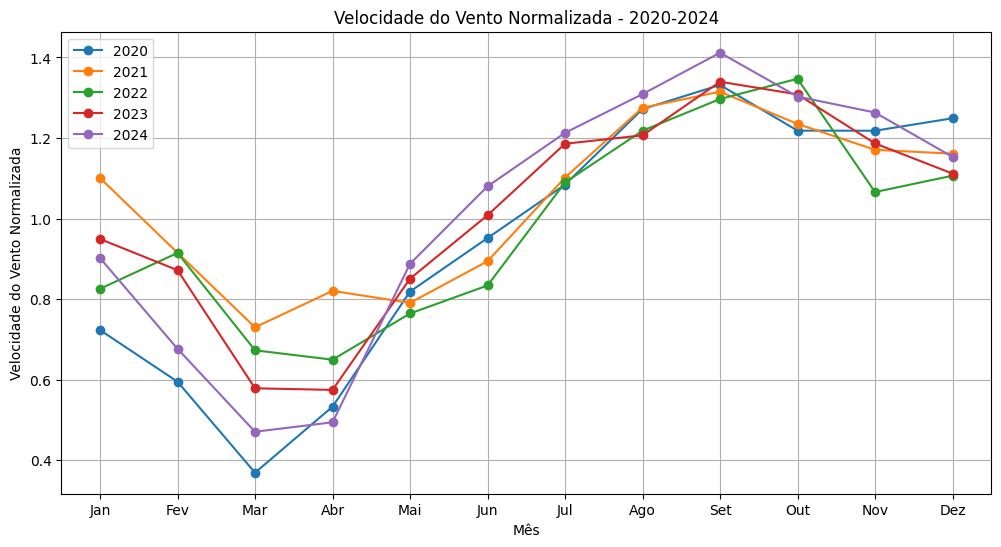

In [65]:
#################### Coletas dos Dados para plotagem das curvas do vento mensal ####################
# Export to CSV
tabela_dados.to_csv('WindData_SinglePoint.csv', index=False)
print('Exportação completada!')

# Load data
data = pd.read_csv('WindData_SinglePoint.csv')

# Converter a coluna de Tempo para datatime
data['Time'] = pd.to_datetime(data['Time'])

# Calculate wind speed magnitude and normalization
data['VelocidadeVento'] = np.sqrt(data['U100']**2 + data['V100']**2)
media_vento = data['VelocidadeVento'].mean()
data['VelocidadeVentoNormalizada'] = data['VelocidadeVento'] / media_vento

# Adicionar colunas de mês e ano
data['Month'] = data['Time'].dt.month
data['Year'] = data['Time'].dt.year

# Criar tabelas anuais
anos_unicos = data['Year'].unique()

# Dicionário para armazenar DataFrames anuais
annual_data = {}

for ano_corrente in anos_unicos:
    # Filtrar dados para o ano atual
    dati_anno = data[data['Year'] == ano_corrente]
    
    # Selecionar colunas necessárias
    dados_ano_reduzido = dati_anno[['Latitude', 'Longitude', 'Month', 'VelocidadeVentoNormalizada']]
    
    # Criar nome de variável dinâmico
    nome_tabella = f'data_{ano_corrente}'
    
    # Armazenar no dicionário (melhor que variáveis dinâmicas)
    annual_data[nome_tabella] = dados_ano_reduzido
    
    print(f'Tabela criada: {nome_tabella} com {len(dados_ano_reduzido)} observações')

# Gráfico comparativo com marcadores (com anos dinâmicos)
plt.figure(figsize=(12, 6))
plt.grid(True)

# Obter anos mínimo e máximo
anos_unicos = data['Year'].unique()
anno_min = min(anos_unicos)
anno_max = max(anos_unicos)

# Configurações do gráfico
plt.title(f'Velocidade do Vento Normalizada - {anno_min}-{anno_max}')
plt.xlabel('Mês')
plt.ylabel('Velocidade do Vento Normalizada')
plt.xlim(0.5, 12.5)
plt.xticks(range(1, 13), ['Jan','Fev','Mar','Abr','Mai','Jun',
                         'Jul','Ago','Set','Out','Nov','Dez'])

# Plotar os dados de cada ano
for nome_tabella, df in annual_data.items():
    # Agrupar por mês e calcular a média
    monthly_avg = df.groupby('Month')['VelocidadeVentoNormalizada'].mean()
    year = nome_tabella.split('_')[1]
    plt.plot(monthly_avg.index, monthly_avg.values, marker='o', label=year)

plt.legend()
plt.show()

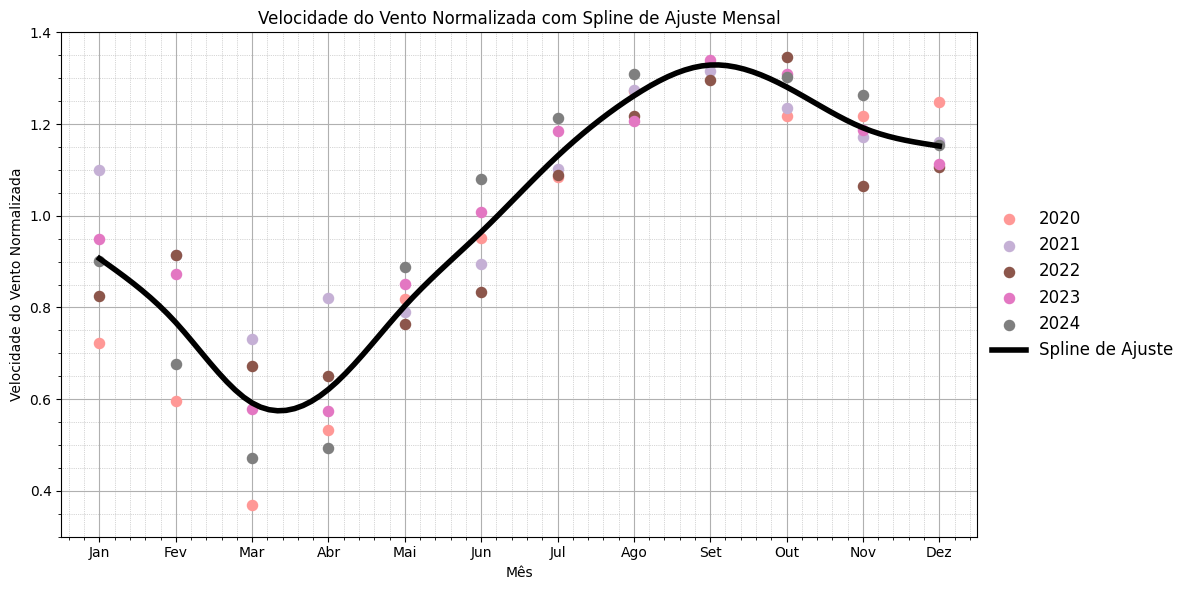

In [30]:
# Calcular curva de ajuste mensal
monthly_fit = data.groupby('Month')['VelocidadeVentoNormalizada'].mean().reset_index()
monthly_fit = monthly_fit.sort_values('Month')  # Ordenar meses

# Calcular ajuste spline mensal
mesi = monthly_fit['Month'].values
valori_medi = monthly_fit['VelocidadeVentoNormalizada'].values

# Criar spline cúbico suavizado (com parâmetro de suavização)
x_fine = np.linspace(1, 12, 100)  # 100 pontos para curva suave
spline = make_smoothing_spline(mesi, valori_medi, lam=0.05)  
y_fit = spline(x_fine)

# Criar figura com ajuste spline
plt.figure(figsize=(12, 6))
plt.grid(True, which='both')
plt.gca().set_axisbelow(True)  # Grade atrás dos elementos do gráficos

# Configurações gráficas aprimoradas
plt.title('Velocidade do Vento Normalizada com Spline de Ajuste Mensal')
plt.xlabel('Mês')
plt.ylabel('Velocidade do Vento Normalizada')
plt.xlim(0.5, 12.5)
plt.ylim(0.3, 1.4)  # Ajustar com base no intervalo dos seus dados
plt.xticks(range(1, 13), ['Jan','Fev','Mar','Abr','Mai','Jun',
                         'Jul','Ago','Set','Out','Nov','Dez'])

# Plotar dados anuais com estilo simplificado
color_map = plt.cm.tab20(np.linspace(0, 1, 12))  # Usando o colormap tab20

for anno in range(anno_min, anno_max + 1):
    nome_tabella = f'data_{anno}'
    if nome_tabella in annual_data:
        dati_anno = annual_data[nome_tabella]
        plt.scatter(dati_anno['Month'], 
                   dati_anno['VelocidadeVentoNormalizada'],
                   s=50,  # Tamanho aumentado
                   c=[color_map[anno % 12]],  # Percorrer as cores ciclicamente
                   marker='o',
                   linewidths=1.2,
                   edgecolors=color_map[anno % 12],
                   label=str(anno))

# Plotar spline ajustado com maior espessura
plt.plot(x_fine, y_fit,
         color='black',  # Preto puro
         linewidth=4,
         label='Spline de Ajuste')

# Legenda de coluna única com dimensões aumentadas
plt.legend(loc='center left', 
           bbox_to_anchor=(1, 0.5),
           ncol=1,  # Alterado de 2 para 1
           fontsize=12,
           frameon=False)  # Remover borda do gráfico (box off)

# Adicionar grade secundária
plt.grid(visible=True, which='minor', linestyle=':', linewidth=0.5)
plt.minorticks_on()
plt.tight_layout()  # Ajustar layout para evitar sobreposição de elementos
plt.show()

In [20]:
########################## Exportar os Dados de Velocidade com Spline de Ajuste ############################
month=['Jan','Fev','Mar','Abr','Mai','Jun', 'Jul','Ago','Set','Out','Nov','Dez']
data_spline = pd.DataFrame({
    'Mês':month,
    'Wind_Spline': [y_fit]*len(month)
    
})
data_spline_transposed = pd.DataFrame([y_fit]*len(month)).T
data_spline_transposed.columns = month
print(data_spline_transposed)

#Export to CSV
data_spline_transposed.to_csv('WindData_Spline.csv', index=False)
print('Exportação completada!')

         Jan       Fev       Mar       Abr       Mai       Jun       Jul  \
0   0.906661  0.906661  0.906661  0.906661  0.906661  0.906661  0.906661   
1   0.893507  0.893507  0.893507  0.893507  0.893507  0.893507  0.893507   
2   0.880178  0.880178  0.880178  0.880178  0.880178  0.880178  0.880178   
3   0.866496  0.866496  0.866496  0.866496  0.866496  0.866496  0.866496   
4   0.852288  0.852288  0.852288  0.852288  0.852288  0.852288  0.852288   
..       ...       ...       ...       ...       ...       ...       ...   
95  1.164647  1.164647  1.164647  1.164647  1.164647  1.164647  1.164647   
96  1.161093  1.161093  1.161093  1.161093  1.161093  1.161093  1.161093   
97  1.157892  1.157892  1.157892  1.157892  1.157892  1.157892  1.157892   
98  1.154925  1.154925  1.154925  1.154925  1.154925  1.154925  1.154925   
99  1.152076  1.152076  1.152076  1.152076  1.152076  1.152076  1.152076   

         Ago       Set       Out       Nov       Dez  
0   0.906661  0.906661  0.906661

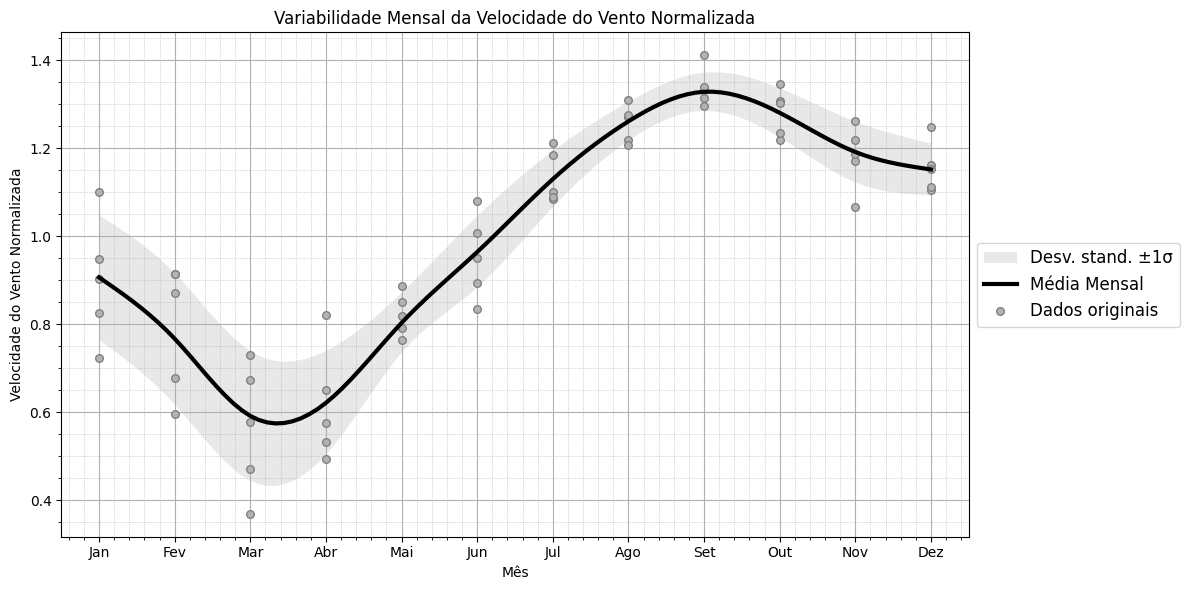

In [31]:
# Primeira Figura: Variabilidade mensal com faixas de desvio padrão
plt.figure(figsize=(12, 6))
plt.grid(True, which='both')
plt.gca().set_axisbelow(True)

# Calcular média e desvio padrão mensais
monthly_stats = data.groupby('Month')['VelocidadeVentoNormalizada'].agg(['mean', 'std']).reset_index()
monthly_stats = monthly_stats.sort_values('Month')

# Preparar os dados
mesi = monthly_stats['Month'].values
media = monthly_stats['mean'].values
dev_std = monthly_stats['std'].values

# Criar curvas suavizadas
x_fine = np.linspace(1, 12, 100)
spline_media = make_smoothing_spline(mesi, media, lam=0.05)
y_media = spline_media(x_fine)

spline_std = make_smoothing_spline(mesi, dev_std, lam=0.05)
y_std = spline_std(x_fine)

# Plotar faixa de desvio padrão
plt.fill_between(x_fine, 
                 y_media - y_std, 
                 y_media + y_std,
                 color=[0.7, 0.7, 0.7],
                 alpha=0.3,
                 edgecolor='none',
                 label='Desv. stand. ±1σ')

# Plotar média mensal
plt.plot(x_fine, y_media,
         color='black',
         linewidth=3,
         label='Média Mensal')

# Plotar dados originais para contexto (opcional)
plt.scatter(data['Month'], 
            data['VelocidadeVentoNormalizada'],
            s=30,
            color=[0.5, 0.5, 0.5],
            marker='o',
            facecolor=[0.7, 0.7, 0.7],
            label='Dados originais')

# Formatação
plt.title('Variabilidade Mensal da Velocidade do Vento Normalizada')
plt.xlabel('Mês')
plt.ylabel('Velocidade do Vento Normalizada')
plt.xlim(0.5, 12.5)
plt.xticks(range(1, 13), ['Jan','Fev','Mar','Abr','Mai','Jun',
                         'Jul','Ago','Set','Out','Nov','Dez'])
plt.legend(loc='center left', 
           bbox_to_anchor=(1, 0.5),
           ncol=1,
           fontsize=12)
plt.grid(visible=True, which='minor', linestyle=':', linewidth=0.5)
plt.minorticks_on()
plt.tight_layout()
plt.show()



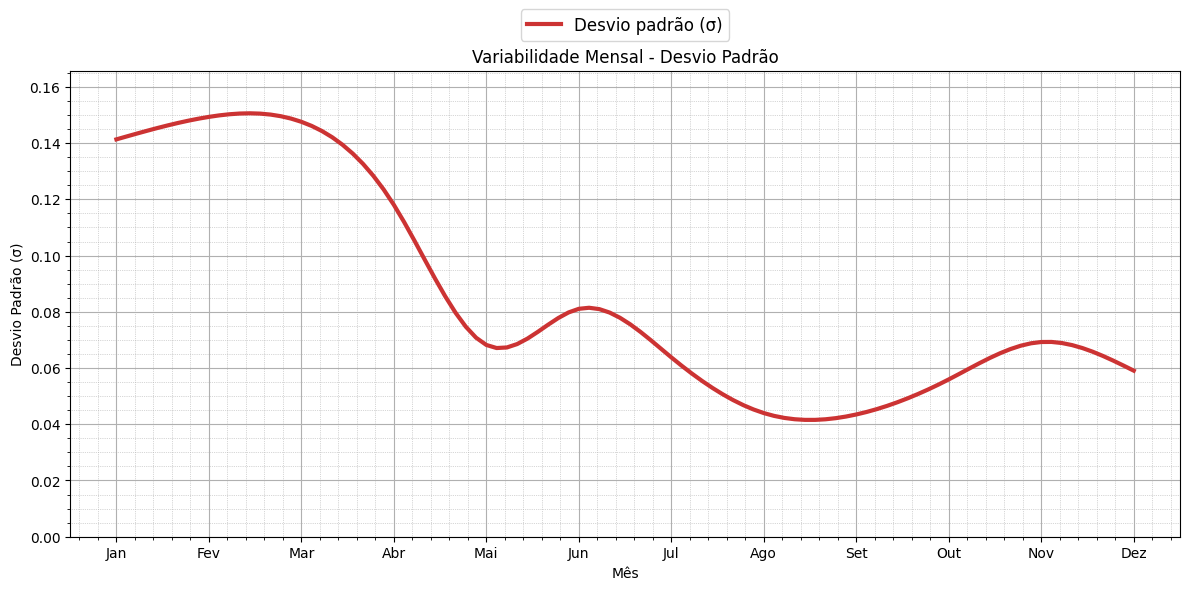

In [32]:
# Segunda Figura: Apenas desvio padrão mensal
plt.figure(figsize=(12, 6))
plt.grid(True, which='both')
plt.gca().set_axisbelow(True)

# Calcular desvio padrão mensal
monthly_std = data.groupby('Month')['VelocidadeVentoNormalizada'].std().reset_index()
monthly_std = monthly_std.sort_values('Month')

# Suavização com spline
spline_std = make_smoothing_spline(monthly_std['Month'].values, 
                                  monthly_std['VelocidadeVentoNormalizada'].values,
                                  lam=0.05)
y_std_smooth = spline_std(x_fine)

# Plotar desvio padrão
plt.plot(x_fine, y_std_smooth,
         color=[0.8, 0.2, 0.2],  # Vermelho escuro
         linewidth=3,
         label='Desvio padrão (σ)')

# Formatação
plt.title('Variabilidade Mensal - Desvio Padrão')
plt.xlabel('Mês')
plt.ylabel('Desvio Padrão (σ)')
plt.xlim(0.5, 12.5)
plt.ylim(0, max(y_std_smooth)*1.1)  # Ajuste automático do eixo Y
plt.xticks(range(1, 13), ['Jan','Fev','Mar','Abr','Mai','Jun',
                         'Jul','Ago','Set','Out','Nov','Dez'])

# Grade e legenda
plt.grid(visible=True, which='minor', linestyle=':', linewidth=0.5)
plt.minorticks_on()
plt.legend(loc='upper center',
           bbox_to_anchor=(0.5, 1.15),
           ncol=1,
           fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
#################### Dados do Desvio Padrão da Viabilidade Mensal ############################
month=['Jan','Fev','Mar','Abr','Mai','Jun', 'Jul','Ago','Set','Out','Nov','Dez']
data_desvio = pd.DataFrame({
    'Mês':month,
    'Desvio_Padrão': [y_std_smooth]*len(month)
})

data_desvio_transposed = pd.DataFrame([y_std_smooth]*len(month)).T
data_desvio_transposed.columns = month
print(data_desvio_transposed)
print(data_desvio_transposed.head())
# Exportar CSV
data_desvio.to_csv('Desvio_Padrão.csv', index=False)
print('Exportação completada!')

         Jan       Fev       Mar       Abr       Mai       Jun       Jul  \
0   0.141334  0.141334  0.141334  0.141334  0.141334  0.141334  0.141334   
1   0.142373  0.142373  0.142373  0.142373  0.142373  0.142373  0.142373   
2   0.143401  0.143401  0.143401  0.143401  0.143401  0.143401  0.143401   
3   0.144406  0.144406  0.144406  0.144406  0.144406  0.144406  0.144406   
4   0.145378  0.145378  0.145378  0.145378  0.145378  0.145378  0.145378   
..       ...       ...       ...       ...       ...       ...       ...   
95  0.065806  0.065806  0.065806  0.065806  0.065806  0.065806  0.065806   
96  0.064299  0.064299  0.064299  0.064299  0.064299  0.064299  0.064299   
97  0.062640  0.062640  0.062640  0.062640  0.062640  0.062640  0.062640   
98  0.060880  0.060880  0.060880  0.060880  0.060880  0.060880  0.060880   
99  0.059068  0.059068  0.059068  0.059068  0.059068  0.059068  0.059068   

         Ago       Set       Out       Nov       Dez  
0   0.141334  0.141334  0.141334

### **Estimativa da Produção Energética Mensal | Gerador Eólico**

#### **Implementação da Curva de Densidade de Pontência Mensal**
Para estimar a produção energética mensal de um gerador eólico utilizando a densidade de potência por metro quadrado obtido dos dados de velocidade durante os meses do ano, siga os seguintes passos:

**Definição das Quantidades**
- $V_{vento}$: Velocidade do Vento Mensal (m/s).
- $p{o}$: Massa específica do ar (kg/m³).
- $D$ : Densidade de Potência (w/m^2)

**Equação da Densidade de Potência**

${D}$ = $\frac{V^2*p}{2}$.


**Referência Bibliográfica**
- PINTO, Milton. Fundamentos de energia eólica. Rio de Janeiro: LTC, 2013 

Seguindo esses passos, é possível estimar a produção energética mensal do gerador eólico e a densidade de energia produzida por metro quadrado com base no fator de capacidade obtido dos dados de velocidade durante os meses do ano.

Tabela criada: data_2020 com 12 observações
Tabela criada: data_2021 com 12 observações
Tabela criada: data_2022 com 12 observações
Tabela criada: data_2023 com 12 observações
Tabela criada: data_2024 com 12 observações


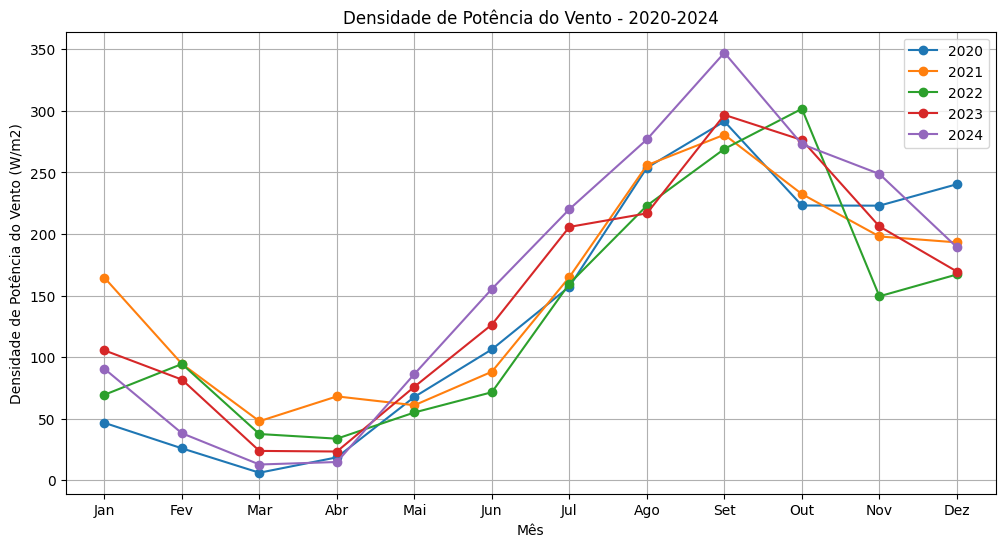

In [33]:

p_mass_específic_do_ar = 1.225 # Massa específica do ar ρ = 1,225 kg/m³ 
wind_data = np.sqrt(data['U100']**2 + data['V100']**2)
data['DensidadedePotenciadoVento'] = (0.5)*(p_mass_específic_do_ar)*(wind_data)**3

# Adicionar colunas de mês e ano
data['Month'] = data['Time'].dt.month
data['Year'] = data['Time'].dt.year

# Criar tabelas anuais
anos_unicos = data['Year'].unique()

# Dicionário para armazenar DataFrames anuais
annual_data = {}

for ano_corrente in anos_unicos:
    # Filtrar dados para o ano atual
    dati_anno = data[data['Year'] == ano_corrente]
    
    # Selecionar colunas necessárias
    dados_ano_reduzido = dati_anno[['Latitude', 'Longitude', 'Month', 'DensidadedePotenciadoVento']]
    
    # Criar nome de variável dinâmico
    nome_tabella = f'data_{ano_corrente}'
    
    # Armazenar no dicionário (melhor que variáveis dinâmicas)
    annual_data[nome_tabella] = dados_ano_reduzido
    
    print(f'Tabela criada: {nome_tabella} com {len(dados_ano_reduzido)} observações')

# Gráfico comparativo com marcadores (com anos dinâmicos)
plt.figure(figsize=(12, 6))
plt.grid(True)

# Obter anos mínimo e máximo
anos_unicos = data['Year'].unique()
anno_min = min(anos_unicos)
anno_max = max(anos_unicos)

# Configurações do gráfico
plt.title(f'Densidade de Potência do Vento - {anno_min}-{anno_max}')
plt.xlabel('Mês')
plt.ylabel('Densidade de Potência do Vento (W/m2)')
plt.xlim(0.5, 12.5)
plt.xticks(range(1, 13), ['Jan','Fev','Mar','Abr','Mai','Jun',
                         'Jul','Ago','Set','Out','Nov','Dez'])

# Plotar os dados de cada ano
for nome_tabella, df in annual_data.items():
    # Agrupar por mês e calcular a média
    monthly_avg = df.groupby('Month')['DensidadedePotenciadoVento'].mean()
    year = nome_tabella.split('_')[1]
    plt.plot(monthly_avg.index, monthly_avg.values, marker='o', label=year)

plt.legend()
plt.show()

#### Implementação da Curva do Fator de Capacidade 
Para estimar a curva do Fator de Capacidade com a Velocidade Média Normalizada Mensal é preciso fazer o produto dos dois valores em função
do decorrer dos meses do ano.

**Definição das Quantidades**
- $FC$: Fator de capacidade (Capacity Factor Class II), obtido dos dados de velocidade durante os meses do ano (%).
- $VN_{med}$: Velocidade Média Normalizada (m/s/m/s)

**Passos para a Estimativa**
1. *Extrair o valor do $FC$ (%) gerado pelo Tiff de acordo com a coordenada dos pontos proposto.
2. *Utilizar os dados gerado do código da Velocidade Média Normalizada
3. *Cálculo necessario para gerar a curva: $X_{mensal}$ = $VN_{med}$ · $FC$

In [ ]:
# Arquivo TIFF
file_path = "C:\\Users\\55889\\OneDrive\\Grupo de Redes Eletricas Inteligentes\\data01_era5\\ceara_capacity_factor_iec_ii.tif"

# Coordenadas de interesse
target_lat = -3.54  #-3.581397, -3.650871
target_lon = -38.88 # -38.847446°, -39.143630


# Lista para armazenar o resultado
data = []

# Abre o arquivo raster
with rasterio.open(file_path) as dataset:
    # Converte coordenadas (lon, lat) para índices de linha e coluna
    row, col = dataset.index(target_lon, target_lat)
    
    # Lê o valor do fator de capacidade na posição (row, col)
    capacity_factor = dataset.read(1)[row, col]
    
    # Verifica se o valor é válido (não é NaN ou nodata)
    if not pd.isna(capacity_factor) and capacity_factor != dataset.nodata:
        data.append({
            'Longitude': target_lon,
            'Latitude': target_lat,
            'Capacity_Factor': capacity_factor
        })

# Cria o DataFrame
df = pd.DataFrame(data)

# Exibe o resultado
if not df.empty:
    print("Fator de capacidade encontrado:")
    print(df)
else:
    print("Nenhum dado válido encontrado para as coordenadas fornecidas.")


#print(capacity_factor)

Fator de capacidade encontrado:
   Longitude  Latitude  Capacity_Factor
0     -38.88     -3.54         0.488261


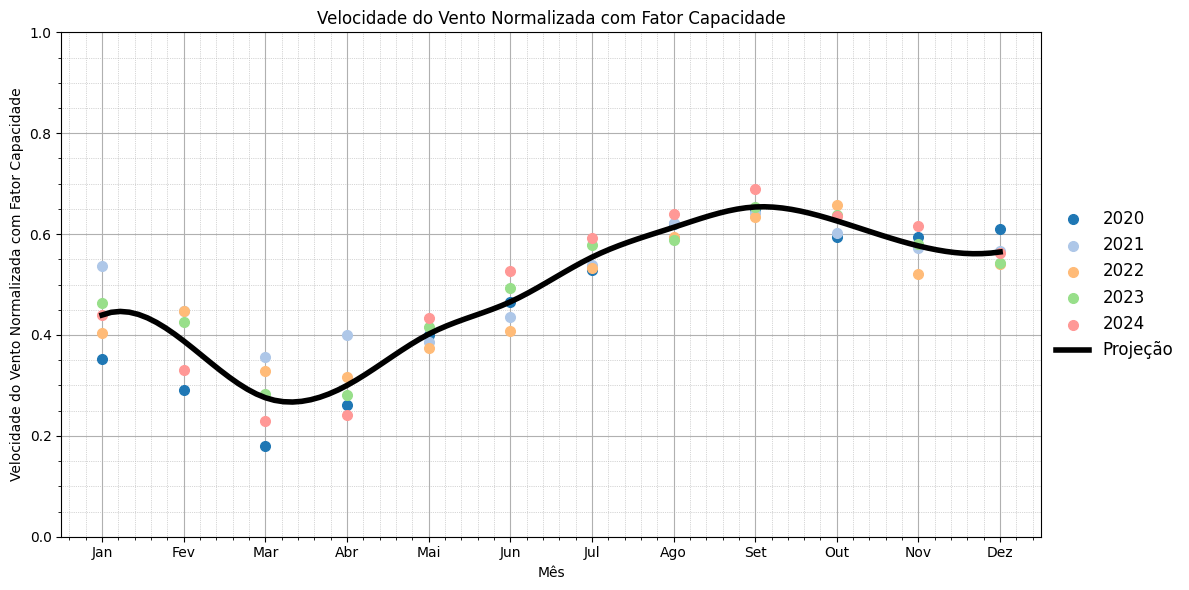

In [66]:
#Velocidade média do vento
media_vento = data['VelocidadeVento'].mean()
# Normalizar a velocidade do vento
data['VelocidadeVentoNormalizada'] = data['VelocidadeVento'] / media_vento

# Calcular o produto com fator de capacidade
data['ProdutoFCVelocidadeVentoNormalizada'] = (capacity_factor)* data['VelocidadeVentoNormalizada'] # Xmensal = VNmed*FC

for ano_corrente in anos_unicos:
    # Filtrar dados para o ano atual
    dati_anno = data[data['Year'] == ano_corrente]
    
    # Selecionar colunas necessárias
    dados_ano_reduzido = dati_anno[['Latitude', 'Longitude', 'Month', 'ProdutoFCVelocidadeVentoNormalizada']]
    
    # Criar nome de variável dinâmico
    nome_tabella = f'data_{ano_corrente}'
    
    # Armazenar no dicionário (melhor que variáveis dinâmicas)
    annual_data[nome_tabella] = dados_ano_reduzido


# Calcular curva de ajuste mensal
monthly_fit = data.groupby('Month')['ProdutoFCVelocidadeVentoNormalizada'].mean().reset_index()
monthly_fit = monthly_fit.sort_values('Month')  # Ordenar meses

# Calcular ajuste spline mensal
mesi = monthly_fit['Month'].values
valori_medi = monthly_fit['ProdutoFCVelocidadeVentoNormalizada'].values

# Criar spline cúbico suavizado (com parâmetro de suavização)
x_fine = np.linspace(1, 12, 100)  # 100 pontos para curva suave
spline = make_interp_spline(mesi, valori_medi, k=3) # Usar make_interp_spline corretamente
y_fit = spline(x_fine)

# Criar figura com ajuste spline
plt.figure(figsize=(12, 6))
plt.grid(True, which='both')
plt.gca().set_axisbelow(True)  # Grade atrás dos elementos do gráfico

# Configurações gráficas aprimoradas
plt.title('Velocidade do Vento Normalizada com Fator Capacidade')
plt.xlabel('Mês')
plt.ylabel('Velocidade do Vento Normalizada com Fator Capacidade')
plt.xlim(0.5, 12.5)
plt.ylim(0.0, 1.0)  # Ajustar com base no intervalo dos seus dados, alterado para começar em 0
plt.xticks(range(1, 13), ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
                           'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])

# Plotar dados anuais com estilo simplificado
color_map = plt.cm.tab20(np.linspace(0, 1, 12))  # Usando o colormap tab20

# Adicione estas linhas para definir anno_min e anno_max
if 'Year' not in data.columns:
    raise ValueError("O DataFrame 'data' deve conter a coluna 'Year'")

anno_min = data['Year'].min()
anno_max = data['Year'].max()

# Verifique se annual_data está definido
try:
    annual_data
except NameError:
    raise NameError("A variável 'annual_data' não está definida.")

for anno in range(anno_min, anno_max + 1):
    nome_tabela = f'data_{anno}'
    if nome_tabela in annual_data:
        dati_anno = annual_data[nome_tabela]
        if 'Month' not in dati_anno.columns or 'ProdutoFCVelocidadeVentoNormalizada' not in dati_anno.columns:
            continue  # Pula para a próxima iteração se as colunas estiverem faltando
        plt.scatter(dati_anno['Month'],
                    dati_anno['ProdutoFCVelocidadeVentoNormalizada'],
                    s=50,  # Tamanho aumentado
                    color=color_map[(anno - anno_min) % 12],  # Correção do índice da cor
                    marker='o',
                    linewidths=0.9,
                    edgecolors=color_map[(anno - anno_min) % 12],  # Correção do índice da cor
                    label=str(anno))

# Plotar spline ajustado com maior espessura
plt.plot(x_fine, y_fit,
         color='black',  # Preto puro
         linewidth=4,
         label='Projeção')

# Legenda de coluna única com dimensões aumentadas
plt.legend(loc='center left',
            bbox_to_anchor=(1, 0.5),
            ncol=1,
            fontsize=12,
            frameon=False)

# Adicionar grade secundária
plt.grid(visible=True, which='minor', linestyle=':', linewidth=0.5)
plt.minorticks_on()
plt.tight_layout()
plt.show()

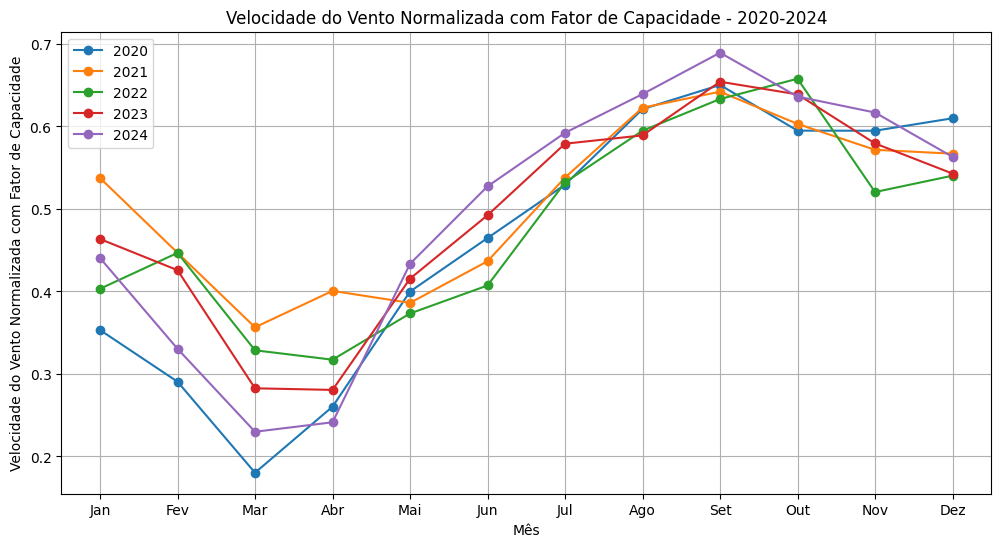

In [67]:
# Adicionar colunas de mês e ano
data['Month'] = data['Time'].dt.month
data['Year'] = data['Time'].dt.year

# Criar tabelas anuais
anos_unicos = data['Year'].unique()

# Dicionário para armazenar DataFrames anuais
annual_data = {}

for ano_corrente in anos_unicos:
    # Filtrar dados para o ano atual
    dati_anno = data[data['Year'] == ano_corrente]
    
    # Selecionar colunas necessárias
    dados_ano_reduzido = dati_anno[['Latitude', 'Longitude', 'Month', 'ProdutoFCVelocidadeVentoNormalizada']]
    
    # Criar nome de variável dinâmico
    nome_tabella = f'data_{ano_corrente}'
    
    # Armazenar no dicionário (melhor que variáveis dinâmicas)
    annual_data[nome_tabella] = dados_ano_reduzido
    
# Gráfico comparativo com marcadores (com anos dinâmicos)
plt.figure(figsize=(12, 6))
plt.grid(True)

# Obter anos mínimo e máximo
anos_unicos = data['Year'].unique()
anno_min = min(anos_unicos)
anno_max = max(anos_unicos)

# Configurações do gráfico
plt.title(f'Velocidade do Vento Normalizada com Fator de Capacidade - {anno_min}-{anno_max}')
plt.xlabel('Mês')
plt.ylabel('Velocidade do Vento Normalizada com Fator de Capacidade')
plt.xlim(0.5, 12.5)
plt.xticks(range(1, 13), ['Jan','Fev','Mar','Abr','Mai','Jun',
                         'Jul','Ago','Set','Out','Nov','Dez'])

# Plotar os dados de cada ano
for nome_tabella, df in annual_data.items():
    # Agrupar por mês e calcular a média
    monthly_avg = df.groupby('Month')['ProdutoFCVelocidadeVentoNormalizada'].mean()
    year = nome_tabella.split('_')[1]
    plt.plot(monthly_avg.index, monthly_avg.values, marker='o', label=year)

plt.legend()
plt.show()